# Causal Analysis

This notebook requires the raw latents, which you can compute with the [`compute_latents.py`](./compute_latents.py) notebook.

## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from csi_vae_gumbel.causal_discovery_raw import run_raw_causal_discovery
from csi_vae_gumbel.path_search_from_raw import run_path_search_from_raw
from scipy import stats

from csi_vae_gumbel.settings import Settings

settings = Settings()

IND_TEST = "parcorr"
TAU_MIN = 1
TAU_MAX = settings.test_window_size // settings.train_window_size - 1
PC_ALPHA = 1e-3
STRIDE = settings.train_window_size
USE_FULL_ONEHOT = True
MAX_WORKERS = 12

# Stage 2: path search + deterministic classification
FILTER_THRESHOLD = 0.1
PATH_THRESHOLD = 0.0
MAX_EDGES_PER_PATH = 4
MIN_EDGES_PER_PATH = 2
TOP_PATHS_PER_ACTIVITY = 150
TOP_RULES_PER_ACTIVITY = 50
RULE_MIN_DELTA = 0.0
CLASSIFIER_STRIDE = 75
CLASSIFIER_TRAIN_RATIO = 0.7
SEGMENT_LENGTH = 64
SEGMENT_HOP = 12
MAX_SEGMENTS_PER_ACTIVITY = None
SAVE_FIGS = True

## Causal Analysis

This may take a while to run.

In [ ]:
raw_result = run_raw_causal_discovery(
    settings=settings,
    ind_test_name=IND_TEST,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    pc_alpha=PC_ALPHA,
    stride=STRIDE,
    use_full_onehot=USE_FULL_ONEHOT,
    max_workers=MAX_WORKERS,
)
raw_result["output_dir"]

## Visualization

GSquared does not distinguish between positive and negative correlations, so we need to compute the correlation matrix separately to determine the sign of each relationship. We will use Pearson correlation for this purpose, which is appropriate for continuous variables.

In [21]:
def compute_gsquared_signs(data: np.ndarray, val_matrix: np.ndarray) -> None:
    """For each link found by Tigramite (nonzero in val_matrix), compute the Spearman correlation."""
    n_vars = val_matrix.shape[0]

    for i in range(n_vars):
        for j in range(n_vars):
            for tau in range(TAU_MIN, TAU_MAX + 1):
                # If Tigramite found a link (nonzero value in val_matrix)
                strength = val_matrix[i, j, tau]

                if strength > 0:  # G2 values are always positive
                    # Get the two time-series aligned by the lag (tau)
                    # X is the cause (at t - tau), Y is the effect (at t)
                    y_series = data[tau:, j]
                    x_series = data[:-tau, i]

                    # Calculate Spearman correlation to find the sign
                    res = stats.spearmanr(x_series, y_series)
                    rho = res.statistic  # pyright: ignore[reportAttributeAccessIssue]

                    # OPTIONAL: Manually update val_matrix with the sign for plotting
                    # This makes the red/blue plot work correctly
                    val_matrix[i, j, tau] *= np.sign(rho)

Walk


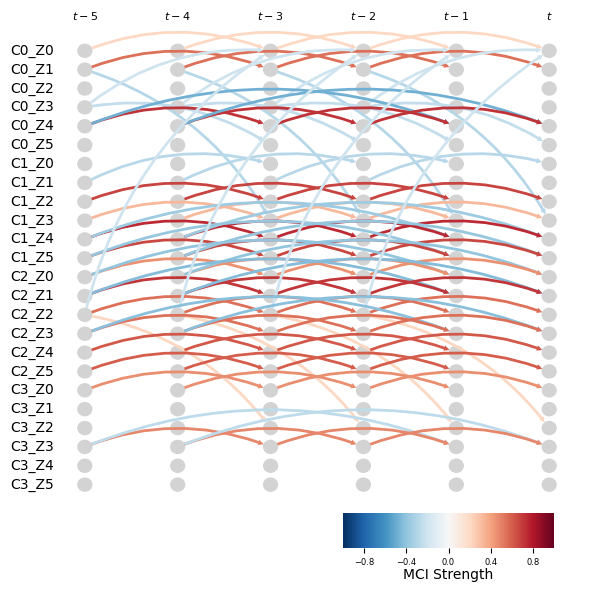

Run


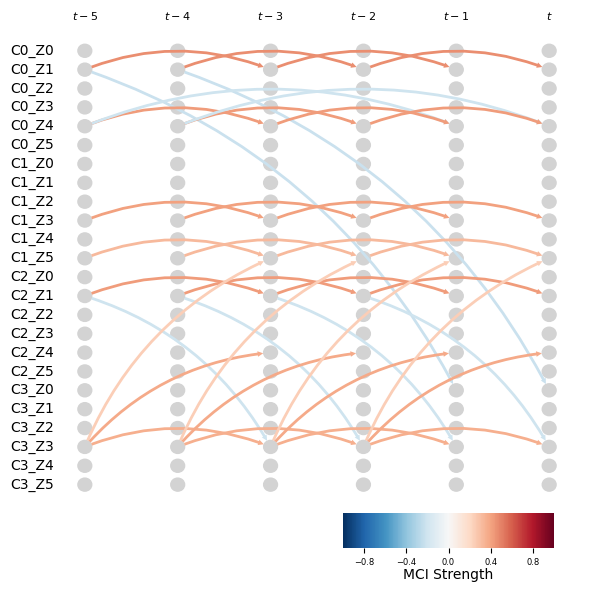

Jump


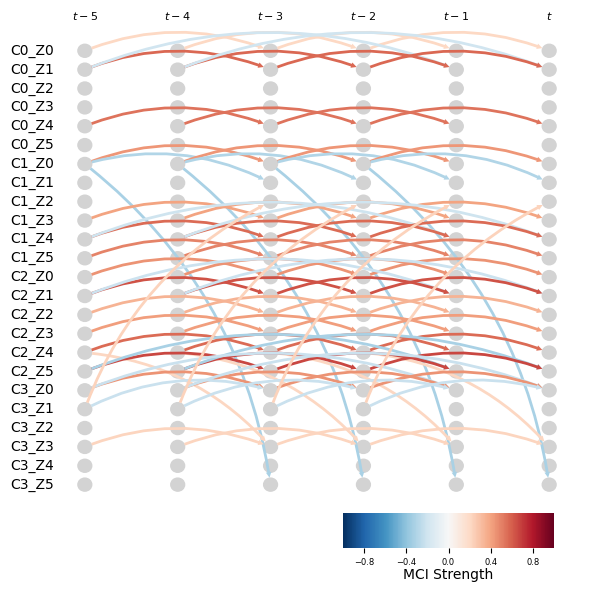

Sit


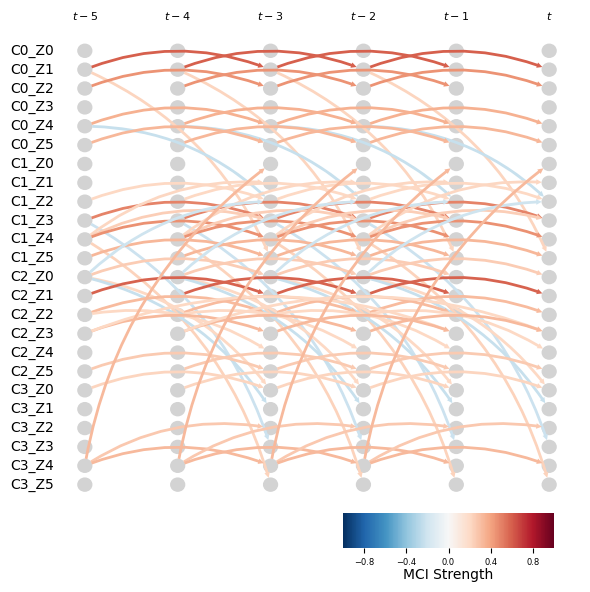

Empty


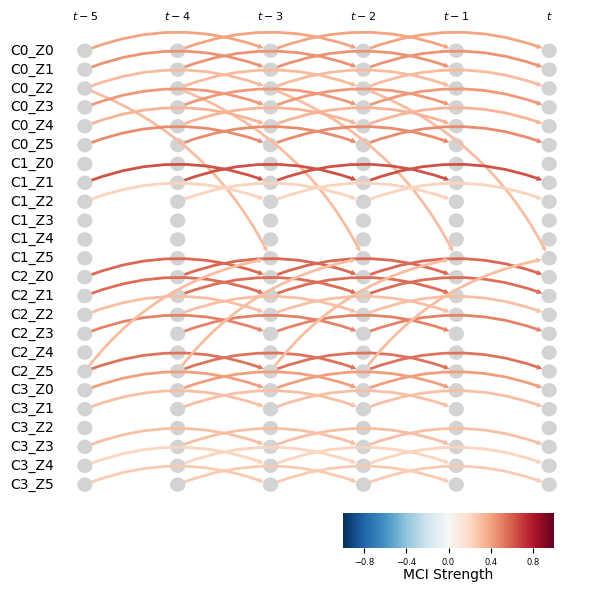

Stand


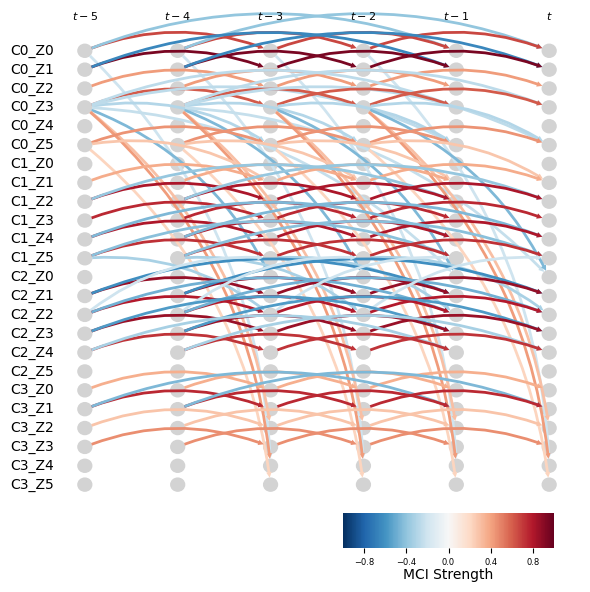

Waving


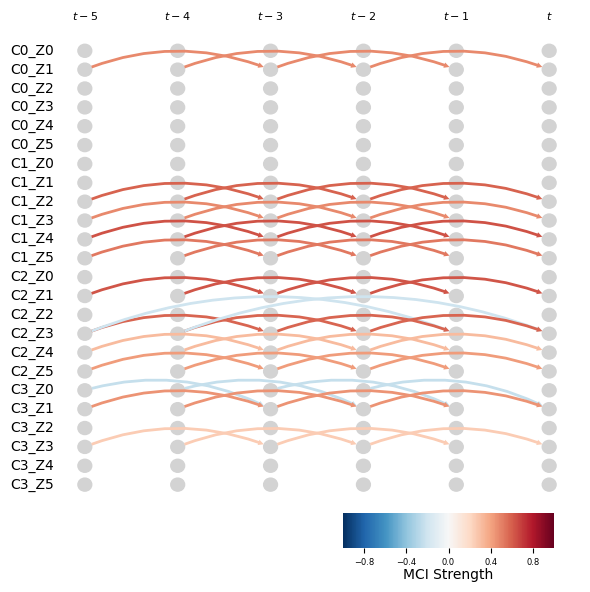

Clap


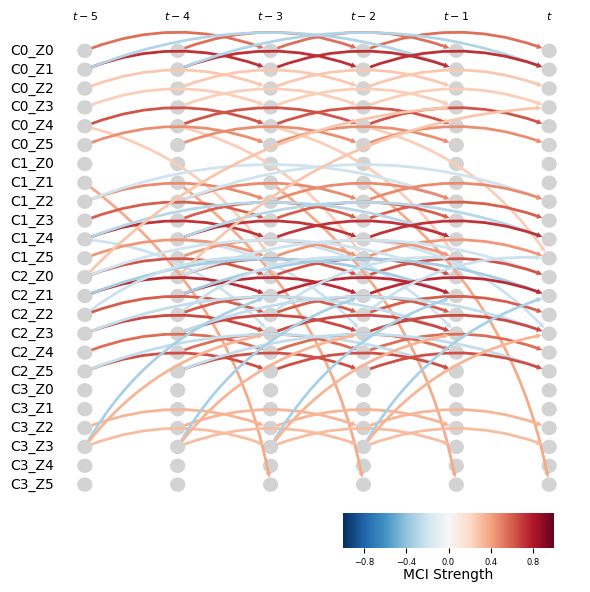

Lay down


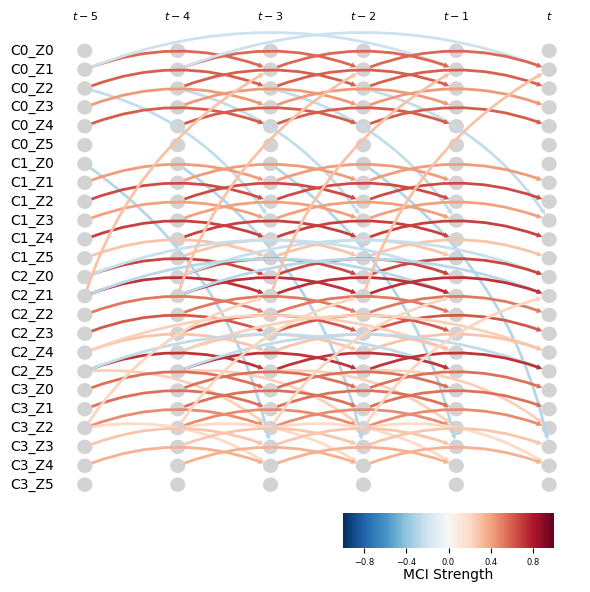

Wipe


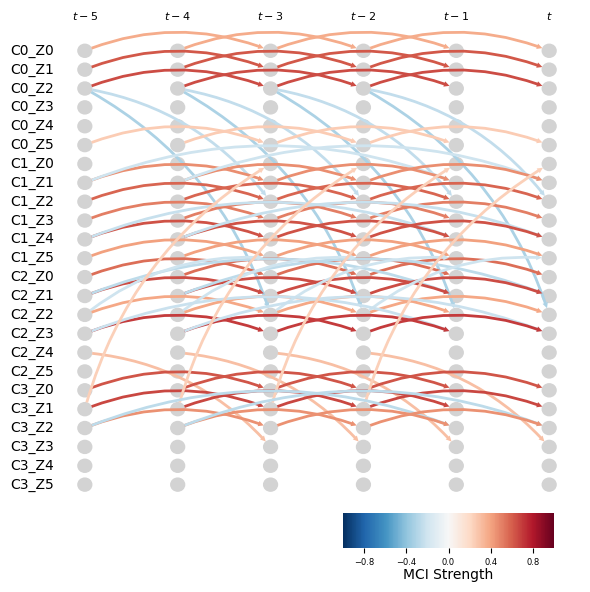

Squat


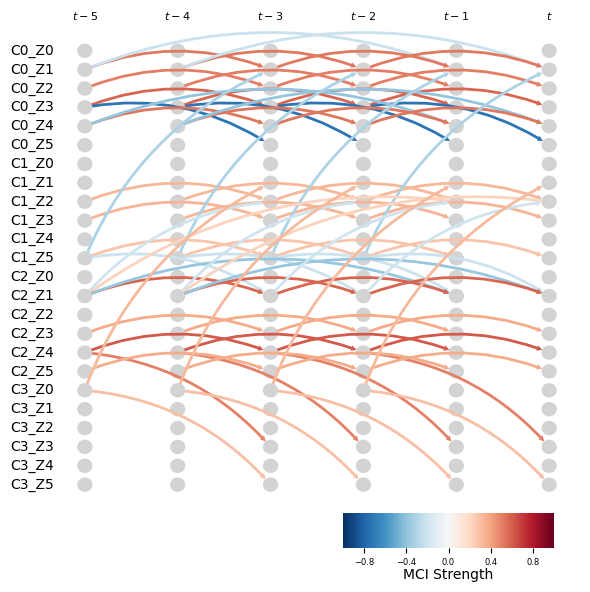

Stretch


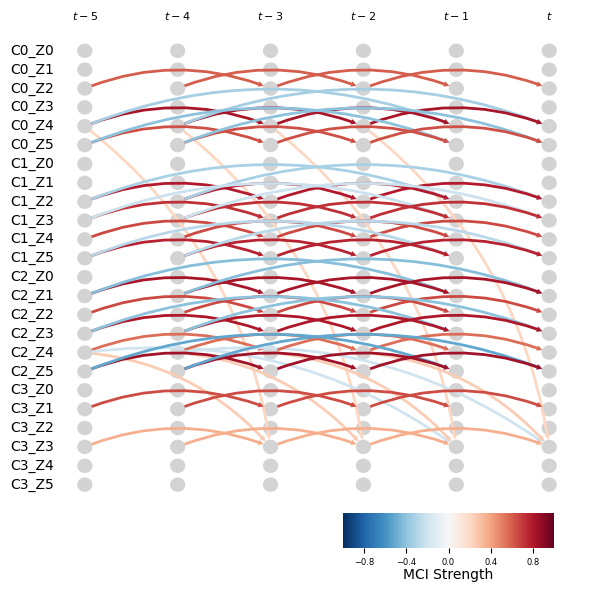

In [5]:
for activity_name in settings.activities:
    out_dir = Path(f"../{settings.study_path}/causal_analysis/{INDEPENDENCE_TEST}")
    val_matrix = np.load(out_dir / f"{activity_name}_val_matrix.npy")
    graph = np.load(out_dir / f"{activity_name}_graph.npy")

    if INDEPENDENCE_TEST == "gsquared":
        compute_gsquared_signs(data, val_matrix)

    # Find indices where the absolute strength is below the threshold and zero them
    weak_links = np.abs(val_matrix) < FILTER_THRESHOLD
    val_matrix[weak_links] = 0
    graph[weak_links] = ""

    # Remove bidirected (confounded) links for better interpretability
    for i in range(graph.shape[0]):
        for j in range(graph.shape[1]):
            for tau in range(graph.shape[2]):
                # Remove bidirected (confounded) links
                if graph[i, j, tau] == "<->" or "o" in graph[i, j, tau]:
                    graph[i, j, tau] = ""
                    val_matrix[i, j, tau] = 0

    print(activity_name)

    fig, ax = tp.plot_time_series_graph(
        figsize=(6,6),
        arrow_linewidth=2,
        arrowhead_size=10,
        node_size=0.03,
        val_matrix=val_matrix,
        graph=graph,
        var_names=var_names,
        link_colorbar_label="MCI Strength",
    )

    plt.tight_layout()
    plt.savefig(out_dir / f"{activity_name}.pdf")
    plt.show()